This is to explore Long Short-Term Memory (LSTM) networks, a type of recurrent neural network (RNN), be use for stock price prediction

In [165]:
#
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

#import os
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error

import yfinance as yf

In [166]:
import warnings
warnings.filterwarnings("ignore")

In [167]:
# Data source from yfinance as below
#   tentatively retreive 3 years stock data

company = "0005.HK"
df_HKstock = yf.download(company, start="2023-01-01", end="2026-01-01",
                    auto_adjust=True ).droplevel('Ticker', axis=1)
df_HKstock

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2023-01-03,37.538025,37.615104,36.227662,36.844303,17994602
2023-01-04,38.540062,38.540062,38.039040,38.116122,20526070
2023-01-05,39.503563,39.619184,39.118162,39.310863,29598352
2023-01-06,40.235825,40.582686,40.043124,40.428525,30945589
2023-01-09,41.083702,41.160784,40.698301,40.968084,25217005
...,...,...,...,...,...
2025-12-23,117.824448,117.920787,117.150060,117.439084,10892666
2025-12-24,119.365898,119.365898,119.365898,119.365898,0
2025-12-29,117.439079,119.173204,117.053716,119.173204,13132355


In [168]:
# Save copy to CSV
df_HKstock.to_csv('0005.HK260101.csv')

In [169]:
#
df_source = pd.read_csv("0005.HK260101.csv")
df_source

,Date,Close,High,Low,Open,Volume
0,2023-01-03,37.538025,37.615104,36.227662,36.844303,17994602
1,2023-01-04,38.540062,38.540062,38.039040,38.116122,20526070
2,2023-01-05,39.503563,39.619184,39.118162,39.310863,29598352
3,2023-01-06,40.235825,40.582686,40.043124,40.428525,30945589
4,2023-01-09,41.083702,41.160784,40.698301,40.968084,25217005
...,...,...,...,...,...,...
730,2025-12-23,117.824448,117.920787,117.150060,117.439084,10892666
731,2025-12-24,119.365898,119.365898,119.365898,119.365898,0
732,2025-12-29,117.439079,119.173204,117.053716,119.173204,13132355
733,2025-12-30,118.498825,118.787850,116.764693,116.764693,11747636


In [170]:
# Set Date
df_source["Date"] = pd.to_datetime(df_source["Date"], format="%Y-%m-%d")
df_source

,Date,Close,High,Low,Open,Volume
0,2023-01-03,37.538025,37.615104,36.227662,36.844303,17994602
1,2023-01-04,38.540062,38.540062,38.039040,38.116122,20526070
2,2023-01-05,39.503563,39.619184,39.118162,39.310863,29598352
3,2023-01-06,40.235825,40.582686,40.043124,40.428525,30945589
4,2023-01-09,41.083702,41.160784,40.698301,40.968084,25217005
...,...,...,...,...,...,...
730,2025-12-23,117.824448,117.920787,117.150060,117.439084,10892666
731,2025-12-24,119.365898,119.365898,119.365898,119.365898,0
732,2025-12-29,117.439079,119.173204,117.053716,119.173204,13132355
733,2025-12-30,118.498825,118.787850,116.764693,116.764693,11747636


In [171]:
df_source.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 735 entries, 0 to 734
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    735 non-null    datetime64[ns]
 1   Close   735 non-null    float64       
 2   High    735 non-null    float64       
 3   Low     735 non-null    float64       
 4   Open    735 non-null    float64       
 5   Volume  735 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 34.6 KB


In [172]:
# Set Date as index - time series data
df_source = df_source.set_index('Date', ) 
df_source.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 735 entries, 2023-01-03 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   735 non-null    float64
 1   High    735 non-null    float64
 2   Low     735 non-null    float64
 3   Open    735 non-null    float64
 4   Volume  735 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 34.5 KB


In [173]:
df = df_source
df

,Close,High,Low,Open,Volume
Date,,,,,
2023-01-03,37.538025,37.615104,36.227662,36.844303,17994602
2023-01-04,38.540062,38.540062,38.039040,38.116122,20526070
2023-01-05,39.503563,39.619184,39.118162,39.310863,29598352
2023-01-06,40.235825,40.582686,40.043124,40.428525,30945589
2023-01-09,41.083702,41.160784,40.698301,40.968084,25217005
...,...,...,...,...,...
2025-12-23,117.824448,117.920787,117.150060,117.439084,10892666
2025-12-24,119.365898,119.365898,119.365898,119.365898,0
2025-12-29,117.439079,119.173204,117.053716,119.173204,13132355


In [174]:
# Data pre-processing
df.isnull().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [175]:
# This is preserve as for handling missing values, if applicable
df.bfill()

,Close,High,Low,Open,Volume
Date,,,,,
2023-01-03,37.538025,37.615104,36.227662,36.844303,17994602
2023-01-04,38.540062,38.540062,38.039040,38.116122,20526070
2023-01-05,39.503563,39.619184,39.118162,39.310863,29598352
2023-01-06,40.235825,40.582686,40.043124,40.428525,30945589
2023-01-09,41.083702,41.160784,40.698301,40.968084,25217005
...,...,...,...,...,...
2025-12-23,117.824448,117.920787,117.150060,117.439084,10892666
2025-12-24,119.365898,119.365898,119.365898,119.365898,0
2025-12-29,117.439079,119.173204,117.053716,119.173204,13132355


In [176]:
# Calculate moving averages and daily returns

df['20-day MA'] = df['Close'].rolling(window=20).mean()
df['50-day MA'] = df['Close'].rolling(window=50).mean()
df['Daily Return'] = df['Close'].pct_change()

In [177]:
# To check NaN
df[df.isna().values==True].drop_duplicates()

,Close,High,Low,Open,Volume,20-day MA,50-day MA,Daily Return
Date,,,,,,,,
2023-01-03,37.538025,37.615104,36.227662,36.844303,17994602,NaN,NaN,NaN
2023-01-04,38.540062,38.540062,38.039040,38.116122,20526070,NaN,NaN,0.026694
2023-01-05,39.503563,39.619184,39.118162,39.310863,29598352,NaN,NaN,0.025000
2023-01-06,40.235825,40.582686,40.043124,40.428525,30945589,NaN,NaN,0.018537
2023-01-09,41.083702,41.160784,40.698301,40.968084,25217005,NaN,NaN,0.021073
2023-01-10,41.083702,41.122242,40.775383,40.968084,15923846,NaN,NaN,0.000000
2023-01-11,41.353493,41.546193,41.083711,41.237871,19895897,NaN,NaN,0.006567
2023-01-12,41.700336,41.700336,41.353478,41.469097,18594710,NaN,NaN,0.008387
2023-01-13,42.779469,42.779469,42.355528,42.394068,31176673,NaN,NaN,0.025878


In [178]:
df = df.dropna()   # Drop all NaN
df

,Close,High,Low,Open,Volume,20-day MA,50-day MA,Daily Return
Date,,,,,,,,
2023-03-16,42.828850,42.948038,42.352089,42.431551,26622653,45.351554,43.985587,-0.023551
2023-03-17,42.749390,42.908310,42.193170,42.908310,19300748,45.245992,44.089815,-0.001855
2023-03-20,40.087486,41.954791,39.491538,41.875333,56886469,44.986138,44.120763,-0.062268
2023-03-21,41.239662,41.358850,40.723172,41.319121,36238398,44.828213,44.155485,0.028742
2023-03-22,42.511009,42.908308,41.994519,42.034251,29346962,44.616309,44.200989,0.030828
...,...,...,...,...,...,...,...,...
2025-12-23,117.824448,117.920787,117.150060,117.439084,10892666,109.548790,105.471437,0.008244
2025-12-24,119.365898,119.365898,119.365898,119.365898,0,110.333966,105.909448,0.013083
2025-12-29,117.439079,119.173204,117.053716,119.173204,13132355,110.955362,106.278315,-0.016142


In [179]:
# Configuration

# For ~ 80:20 Split
test_days = 135

# choose the number of days on which to base our predictions 
nb_days = 60

# Number of days into the future we want to predict
n_steps_out = 30

#
epochsMS=15 
batch_sizeMS = 32
epochs2=30 
batch_size2 = 32

In [180]:
# For normailized Data

# from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))  
scaled_data = scaler.fit_transform(df['Close'].values.reshape(-1,1))

In [181]:
# ADF Test : p-value < 0.05 for stationary data

#from statsmodels.tsa.stattools import adfuller

close_series = df['Close']
def check_stationarity(series):
    result = adfuller(series.dropna())  # Drop NaN values if any
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] < 0.05:
        print("The series is stationary.")
    else:
        print("The series is not stationary.")

check_stationarity(close_series)

ADF Statistic: 1.7834494900432212
p-value: 0.9983156206830707
The series is not stationary.


# To transform time series stationary...
There are three major time series patterns: trend, seasonality, and cycles. Trend and cycles are usually combined into a single component, with a trend-cycle component, a seasonal component, and a remainder component (containing the rest of the time series).

To make time series stationary, the principle is to estimate trend and seasonality, and to remove those from the time series. Then to apply the forecasting technique (i.e here LSTM), the final step being to convert the forcasted values into the original scale by adding the estimated trend and seasonality.

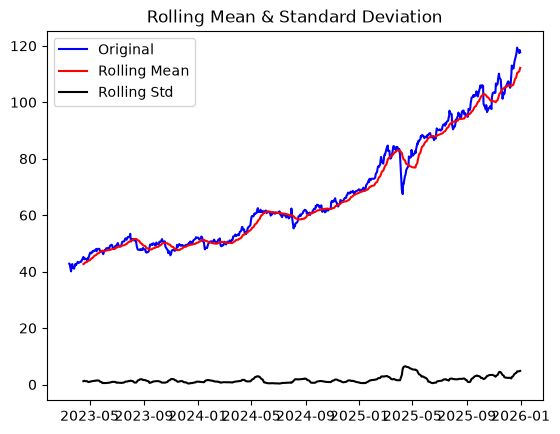

Results of Dickey-Fuller Test:
Test Statistic                   1.783449
p-value                          0.998316
#Lags Used                      14.000000
Number of Observations Used    671.000000
Critical Value (1%)             -3.440133
Critical Value (5%)             -2.865857
Critical Value (10%)            -2.569069
dtype: float64


In [182]:
#... The following cells are use for model(s), such as LSTM in transformation
#... test stationarity with DFT

close_series = df['Close']
def test_stationarity(timeseries):
    '''
    Input: timeseries (dataframe): timeseries for which we want to study the stationarity
    '''
    
    #Determing rolling statistics
    rolmean = timeseries.rolling(20).mean()
    rolstd = timeseries.rolling(20).std()

    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)

    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value',\
                                             '#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

test_stationarity(close_series)

<Figure size 640x480 with 0 Axes>

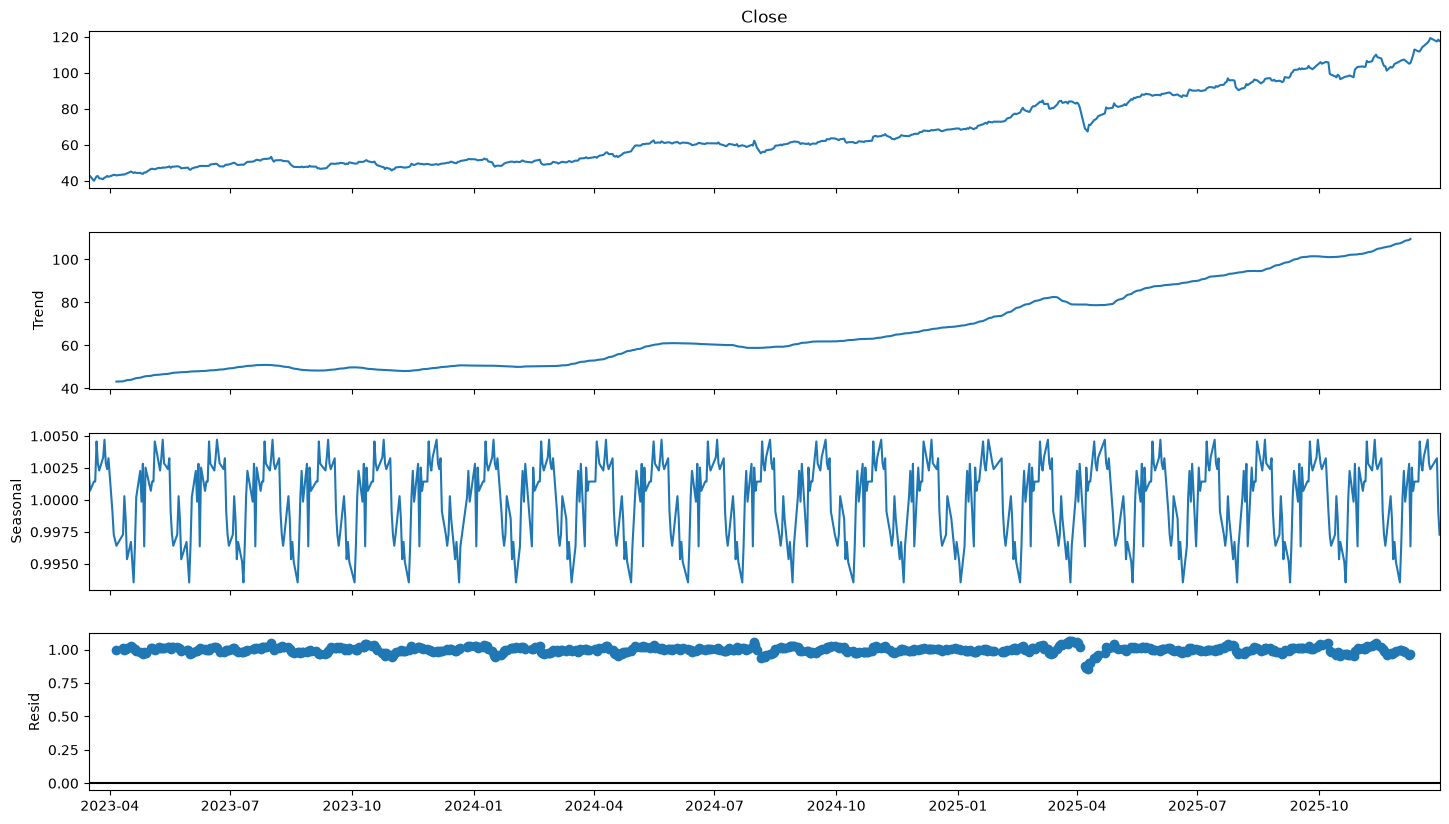

In [183]:
#from statsmodels.tsa.seasonal import seasonal_decompose

#To plot & view the trend and the seasonality
# here set the period to 28 as monthly average 

df_close = df['Close']
result = seasonal_decompose(df_close, model='multiplicative',period=28)
fig = plt.figure()  
fig = result.plot()  
fig.set_size_inches(16, 9)

Text(0.5, 1.0, 'Transformed data')

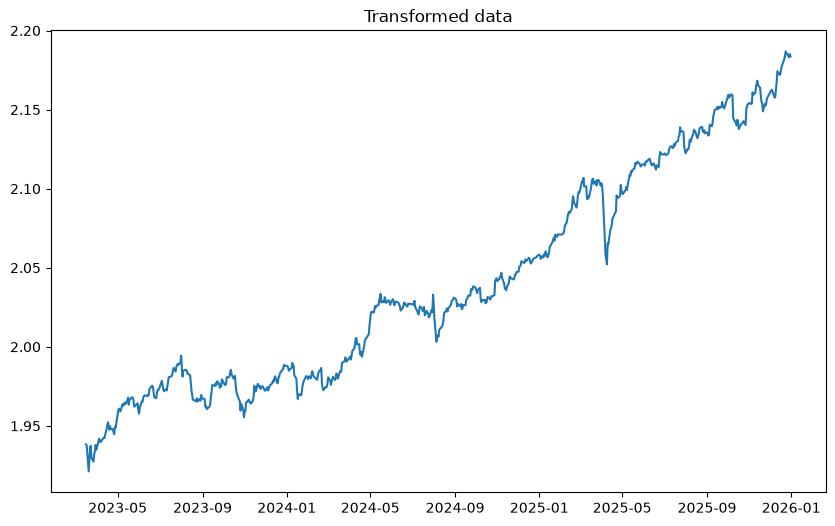

In [184]:
#... To apply log transform to reduce the trends effect while square root transform to flatten 

df_close_log = df_close.apply(np.log)
df_close_tf = df_close_log.apply(np.sqrt)

plt.figure(figsize = (10,6))
plt.plot(df_close_tf)
plt.title('Transformed data')

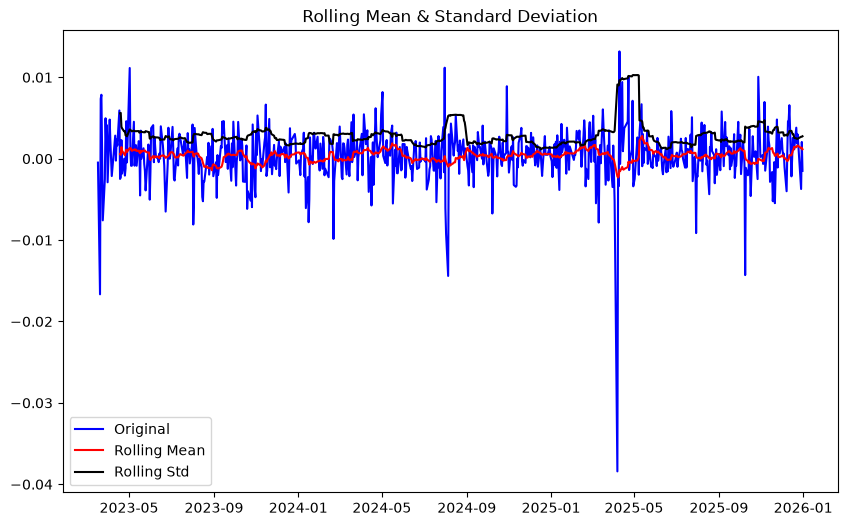

Results of Dickey-Fuller Test:
Test Statistic                -1.560949e+01
p-value                        1.787287e-28
#Lags Used                     2.000000e+00
Number of Observations Used    6.820000e+02
Critical Value (1%)           -3.439975e+00
Critical Value (5%)           -2.865787e+00
Critical Value (10%)          -2.569032e+00
dtype: float64


In [185]:
#... classical methold differenciating to handel with trand and seasonality
df_close_shift = df_close_tf - df_close_tf.shift()

df_close_shift.dropna(inplace=True)
plt.figure(figsize = (10,6))
test_stationarity(df_close_shift)

check p-value

In [186]:
#...MS LSTM
def preprocess_lstm(sequence, n_steps,n_features):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this pattern
        end_ix = i + n_steps
        # check if we are beyond the sequence
        if end_ix >= len(sequence):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
        
    X = np.array(X)
    y = np.array(y)

    X = X.reshape((X.shape[0], X.shape[1], n_features))
    return X, y

# choose the number of days on which to base our predictions 
#nb_days = 60
n_features = 1

X, y = preprocess_lstm(df_close_shift.to_numpy(), nb_days, n_features)

#Split the data set between the training set and the test set (20%)
#test_days = 135 

X_train, y_train = X[:-test_days], y[:-test_days]
X_test, y_test = X[-test_days:], y[-test_days:]

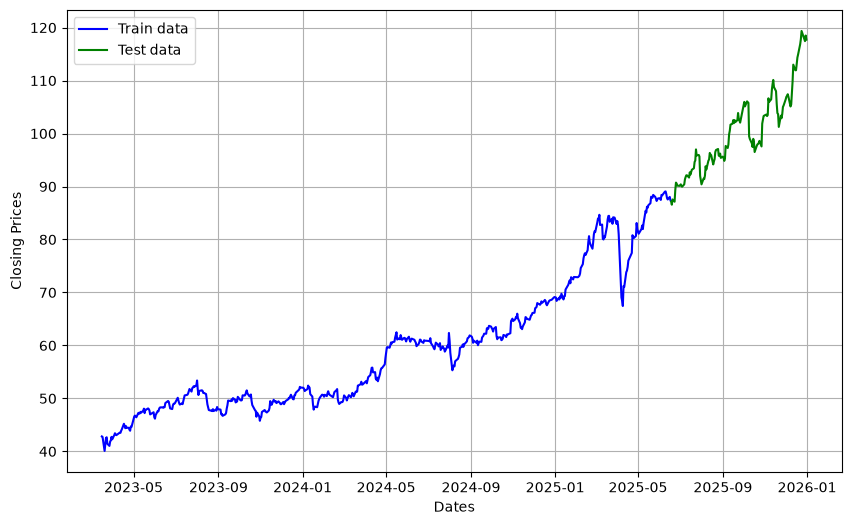

In [187]:
#... Split Data
train_original = df_close.iloc[:-test_days]
test_original = df_close.iloc[-test_days:]

plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(train_original, 'b', label='Train data')
plt.plot(test_original, 'g', label='Test data')
plt.legend()

In [188]:
#... LSTM Vanilla LSTM
def vanilla_LSTM():
    model = Sequential()    
    model.add(LSTM(units=50, input_shape=(nb_days, n_features)))
    model.add(Dense(1))
    return model

#
model = vanilla_LSTM()
model.summary()
model.compile(optimizer='adam', 
              loss='mean_squared_error',
              metrics=[tf.keras.metrics.MeanAbsoluteError()])    

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                       │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [189]:
#...Train and evaluate model
model.fit(X_train, 
          y_train, 
          epochs=epochsMS, 
          batch_size = batch_sizeMS)

Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 2.5781e-05 - mean_absolute_error: 0.0038
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 1.3440e-05 - mean_absolute_error: 0.0026
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 1.1403e-05 - mean_absolute_error: 0.0022
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 1.1226e-05 - mean_absolute_error: 0.0022
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 1.1161e-05 - mean_absolute_error: 0.0022
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 1.1091e-05 - mean_absolute_error: 0.0022
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 1.1237e-05 - mean_absolute_error: 0.0022
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 1.1367e-05 - mean_absolute_error: 0.0022
Epoch 9/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 1.1214e-05 - mean_absolute_error: 0.0022
Epoch 10/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 1.2092e-05 - mean_absolute_error: 0.0023

In [190]:
#...
# Evaluate the model on the test data using
print("Evaluate on test data")
results = model.evaluate(X_test, y_test, batch_size=32)
print("Test MSE:", results[0])
print("Test MAE:", results[1])

Evaluate on test data
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 8.8145e-06 - mean_absolute_error: 0.0021 
Test MSE: 8.814464308670722e-06
Test MAE: 0.002132922876626253


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


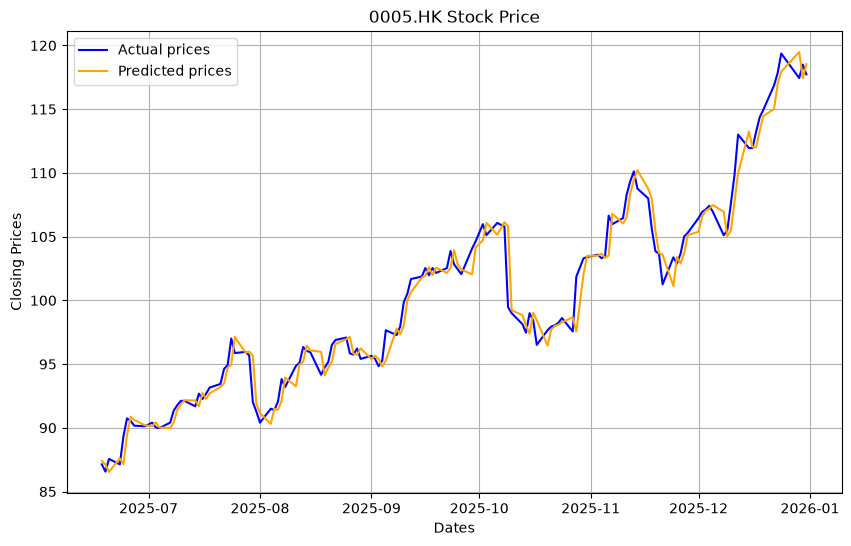

In [191]:
#...
# Prediction
y_pred = model.predict(X_test)

# We create a dataframe from y_pred to have date-time indexes.
pred_data = pd.DataFrame(y_pred[:,0], test_original.index,columns=['Close'])

# Apply inverse transformation from 1.d

# Add the differenciation term
pred_data['Close'] = pred_data['Close'] + df_close_tf.shift().values[-test_days:] 

# Take the square, and the exponent
pred_data = pred_data.apply(np.square)
pred_data = pred_data.apply(np.exp)

# Plot actual prices vs predicted prices 
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(test_original,'b',label='Actual prices')
plt.plot(pred_data, 'orange',label='Predicted prices')
#plt.title(' Stock Price')
plt.title(company + ' Stock Price')

plt.legend()

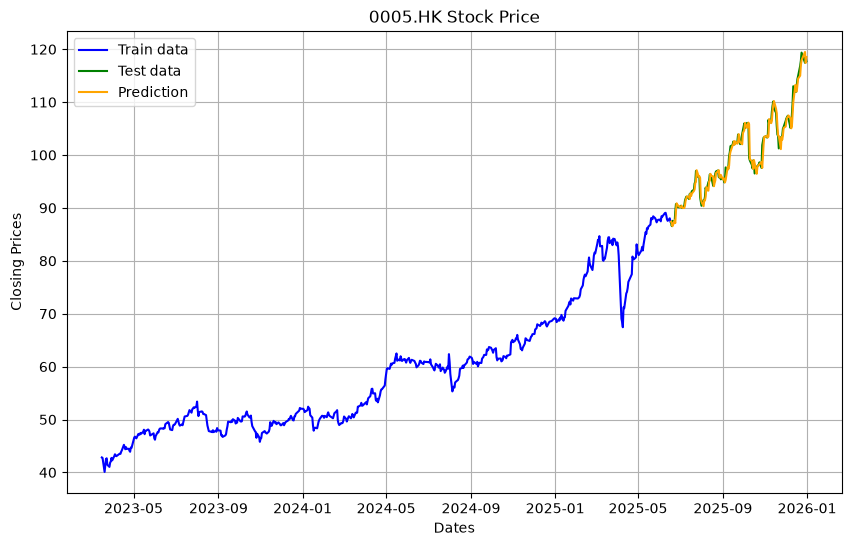

In [192]:
#...
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(train_original, 'b', label='Train data')
plt.plot(test_original, 'g', label='Test data')
plt.plot(pred_data, 'orange', label='Prediction')
plt.title(company + ' Stock Price')
plt.legend()

In [193]:
#...Multiple-Step LSTM
def preprocess_multistep_lstm(sequence, n_steps_in, n_steps_out, features):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the sequence
        if out_end_ix > len(sequence):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix:out_end_ix]
        X.append(seq_x)
        y.append(seq_y)

    X = np.array(X)
    y = np.array(y)

    X = X.reshape((X.shape[0], X.shape[1], n_features))
    
    return X, y

# Number of days into the future we want to predict
#n_steps_out = 30

# choose the number of days on which to base our predictions 
#nb_days = 60

n_features = 1

X, y = preprocess_multistep_lstm(df_close_shift.to_numpy(), nb_days, n_steps_out, n_features)

#
#Split the data set between the training set and the test set (20%)
#test_days = 135 

X_train, y_train = X[:-test_days], y[:-test_days]
X_test, y_test = X[-test_days:], y[-test_days:]

In [194]:
#...
def vanilla_multistep_LSTM():
    model = Sequential()    
    model.add(LSTM(units=50, input_shape=(nb_days, n_features)))
    model.add(Dense(n_steps_out))
    return model

#
model = vanilla_multistep_LSTM()
model.summary()
model.compile(optimizer='adam', 
              loss='mean_squared_error',
              metrics=[tf.keras.metrics.MeanAbsoluteError()])

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_13 (LSTM)                       │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 30)                  │           1,530 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,930 (46.60 KB)

 Trainable params: 11,930 (46.60 KB)

 Non-trainable params: 0 (0.00 B)

In [195]:
#...
model.fit(X_train, 
          y_train, 
          epochs=epochsMS, 
          batch_size = batch_sizeMS)

Epoch 1/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 1.2684e-05 - mean_absolute_error: 0.0024
Epoch 2/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 1.2089e-05 - mean_absolute_error: 0.0023
Epoch 3/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 1.2039e-05 - mean_absolute_error: 0.0023
Epoch 4/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 1.2029e-05 - mean_absolute_error: 0.0023
Epoch 5/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 1.1960e-05 - mean_absolute_error: 0.0023
Epoch 6/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 1.2030e-05 - mean_absolute_error: 0.0023
Epoch 7/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 1.2083e-05 - mean_absolute_error: 0.0023
Epoch 8/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 1.2043e-05 - mean_absolute_error: 0.0023
Epoch 9/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 1.1991e-05 - mean_absolute_error: 0.0023
Epoch 10/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 1.1992e-05 - mean_absolute_error: 0.0023

In [196]:
#...
# Evaluate the model on the test set
print("Evaluate on test data")
results = model.evaluate(X_test, y_test, batch_size=32)

print("Test MSE:", results[0])
print("Test MAE:", results[1])

Evaluate on test data
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 8.4738e-06 - mean_absolute_error: 0.0021
Test MSE: 8.473764864902478e-06
Test MAE: 0.002057701349258423


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step


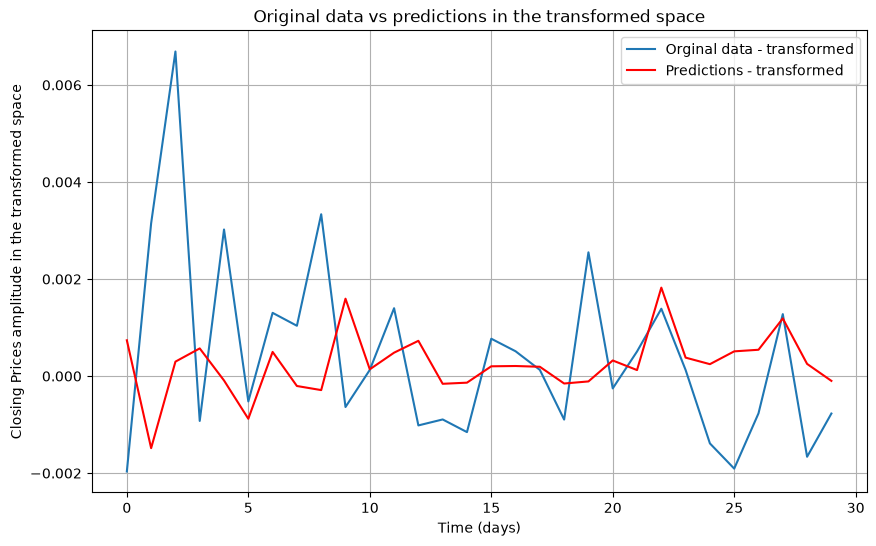

In [197]:
#...
# Prediction
y_pred = model.predict(X_test)

# the_day is the day from which we will study the n_steps_out-th dayS of prediction into 
# the future. Note: The first day start at index 0
the_day = 0
y_pred_days = y_pred[the_day,:]

plt.figure(figsize=(10,6))
plt.grid(True)
plt.plot(y_test[the_day,:],label='Orginal data - transformed')
plt.plot(y_pred_days, color='red',label='Predictions - transformed')
plt.xlabel('Time (days)')
plt.ylabel('Closing Prices amplitude in the transformed space')
plt.title('Original data vs predictions in the transformed space')
plt.legend()

In [198]:
#...
# Apply inverse transformations from 3.a

# Add the differenciation term
pred_diff_cumsum = y_pred_days.cumsum()

base_number = df_close_tf.values[-test_days+the_day+nb_days-1]
idx = test_original.iloc[the_day:the_day+n_steps_out].index

pred_tf = pd.Series(base_number, index=idx)
pred_tf = pred_tf.add(pred_diff_cumsum,fill_value=0)

print(pred_tf)

Date
2025-06-18    2.146370
2025-06-19    2.144884
2025-06-20    2.145182
2025-06-23    2.145753
2025-06-24    2.145663
2025-06-25    2.144783
2025-06-26    2.145282
2025-06-27    2.145078
2025-06-30    2.144789
2025-07-02    2.146384
2025-07-03    2.146524
2025-07-04    2.147006
2025-07-07    2.147733
2025-07-08    2.147575
2025-07-09    2.147439
2025-07-10    2.147641
2025-07-11    2.147849
2025-07-14    2.148041
2025-07-15    2.147888
2025-07-16    2.147778
2025-07-17    2.148100
2025-07-18    2.148225
2025-07-21    2.150048
2025-07-22    2.150428
2025-07-23    2.150674
2025-07-24    2.151184
2025-07-25    2.151727
2025-07-28    2.152915
2025-07-29    2.153166
2025-07-30    2.153068
dtype: float64


In [199]:
#...
# Take the square, and the exponent
pred_log = pred_tf.apply(np.square)
pred = pred_log.apply(np.exp)
print(pred)

Date
2025-06-18    100.173367
2025-06-19     99.536972
2025-06-20     99.664252
2025-06-23     99.908601
2025-06-24     99.869901
2025-06-25     99.493765
2025-06-26     99.706719
2025-06-27     99.619461
2025-06-30     99.496224
2025-07-02    100.179597
2025-07-03    100.239696
2025-07-04    100.447671
2025-07-07    100.761776
2025-07-08    100.693109
2025-07-09    100.634551
2025-07-10    100.721793
2025-07-11    100.811747
2025-07-14    100.894988
2025-07-15    100.828783
2025-07-16    100.781207
2025-07-17    100.920710
2025-07-18    100.974607
2025-07-21    101.769017
2025-07-22    101.935679
2025-07-23    102.043559
2025-07-24    102.267591
2025-07-25    102.506709
2025-07-28    103.032334
2025-07-29    103.143953
2025-07-30    103.100286
dtype: float64


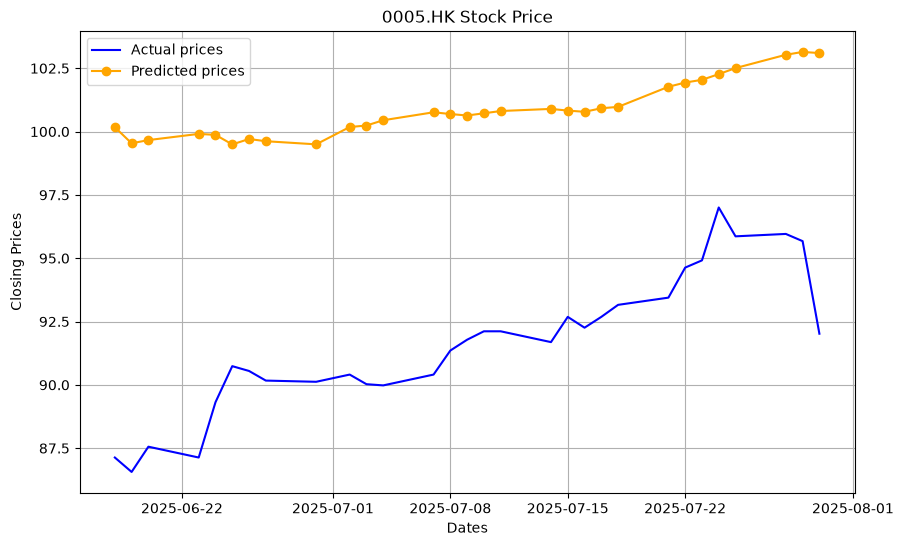

In [200]:
#...
# Plot actual prices vs predicted prices 
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(test_original.iloc[max(0,the_day-30):the_day+n_steps_out],'b',label='Actual prices')
plt.plot(pred, '-o',color='orange',label='Predicted prices')
plt.title(company + ' Stock Price')

plt.legend()

In [201]:
#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt
#import seaborn as sns
from sklearn.metrics import r2_score
import statsmodels.api as sm

# 1. Extract the exact actual prices that align with the prediction period
# Based on your plot, 'pred' starts at 'the_day' and goes forward for 'n_steps_out' steps.
actual_for_pred_period = test_original.iloc[the_day : the_day + n_steps_out]

# 2. Ensure both are flattened 1D arrays/Series with no missing values
y_true = actual_for_pred_period.values.flatten()
y_pred = pred.flatten() if hasattr(pred, 'flatten') else pred

X = sm.add_constant(y_true)

#fit linear regression model
model = sm.OLS(y_pred, X).fit()

#view model summary
summary = model.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.689
Model:                            OLS   Adj. R-squared:                  0.678
Method:                 Least Squares   F-statistic:                     62.11
Date:                Sat, 26 Sep 2026   Prob (F-statistic):           1.39e-08
Time:                        21:16:38   Log-Likelihood:                -27.900
No. Observations:                  30   AIC:                             59.80
Df Residuals:                      28   BIC:                             62.60
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         69.4836      3.984     17.439      0.0

In [202]:
#import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Replace these arrays with your actual test data and model predictions
# Example: y_true (actual market prices), y_pred (your LSTM or ARIMA predictions)
#y_true = np.array([100.0, 102.5, 101.2, 105.0, 107.8])
#y_pred = np.array([101.2, 101.0, 102.0, 104.5, 109.1])

# 2. Calculate Standard Regression Metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)  # Alternative: mean_squared_error(y_true, y_pred, squared=False)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

# 3. Calculate Directional Accuracy (Crucial for price trends)
# Compares if the predicted direction (up/down) matches the actual direction
actual_direction = np.diff(y_true) > 0
predicted_direction = np.diff(y_pred) > 0
directional_accuracy = np.mean(actual_direction == predicted_direction) * 100

# 4. Print Evaluation Results
print("--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE):      {mae:.4f}")
print(f"Mean Squared Error (MSE):       {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Pct Error (MAPE): {mape:.2f}%")
print(f"R² Score (Goodness of Fit):     {r2:.4f}")
print(f"Directional Accuracy (DA):      {directional_accuracy:.2f}%")


--- Model Evaluation Metrics ---
Mean Absolute Error (MAE):      9.2234
Mean Squared Error (MSE):       88.5229
Root Mean Squared Error (RMSE): 9.4087
Mean Absolute Pct Error (MAPE): 10.13%
R² Score (Goodness of Fit):     -11.4455
Directional Accuracy (DA):      55.17%


In [219]:
# Follow from ADF Test if series is stationary
scaler = MinMaxScaler()
df['Close'] = scaler.fit_transform(df[['Close']])

In [220]:
# Train and Verify Split (80:20 Ratio)
#from sklearn.model_selection import train_test_split

def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        dataX.append(dataset[i:(i + look_back)])
        dataY.append(dataset[i + look_back])
    return np.array(dataX), np.array(dataY)

close_values = df['Close'].values 

X, Y = create_dataset(close_values, look_back=30)

trainX, testX, trainY, testY = train_test_split(X, Y, test_size=0.2, shuffle=False)


In [221]:
# Data for LSTM 
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))
testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))

In [215]:
#1 LSTM ***SKIP
model = Sequential()
model.add(LSTM(units=50, input_shape=(30, 1)))
model.add(Dense(units=1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.summary()
model.fit(trainX, trainY, epochs=epochs2, batch_size=batch_size2)

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_18 (LSTM)                       │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0331
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0046
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0020
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 9.7706e-04
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 7.9453e-04
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 7.5218e-04
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 7.1665e-04
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 6.9815e-04
Epoch 9/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 6.9846e-04
Epoch 10/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 6.6905e-04
Epoch 11/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 6.6121e-04
Epoch 12/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 6.5218e-04
Epoch 13/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 6.2959e-04
Epoch 14/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 6.5598e-04
Epoch 15/30
17/17 ━━━━━━━━━

#
LSTM(50 units) → Captures long-term dependencies

Dropout(0.2) → Prevents overfitting

Dense Layers → Produces final prediction

In [222]:
#2 LSTM
#from tensorflow.keras.models import Sequential  
#from tensorflow.keras.layers import LSTM, Dense, Dropout  

model = Sequential([  
    LSTM(units=50, return_sequences=True, input_shape=(trainX.shape[1], 1)),  
    Dropout(0.2),  
    LSTM(units=50, return_sequences=False),  
    Dropout(0.2),  
    Dense(units=25),  
    Dense(units=1)  
])  

model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(trainX, trainY, epochs=epochs2, batch_size=batch_size2)

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0173
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0037
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0018
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0016
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0014
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0013
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0013
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0013
Epoch 9/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0012
Epoch 10/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0012
Epoch 11/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0012
Epoch 12/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0012
Epoch 13/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0011
Epoch 14/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0012
Epoch 15/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0011
Epoc

In [223]:
# Prediction & Result
testPredict = model.predict(testX)
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform(testY.reshape(-1, 1))

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step


In [224]:
#from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(testY, testPredict))
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 0.04314230267751027


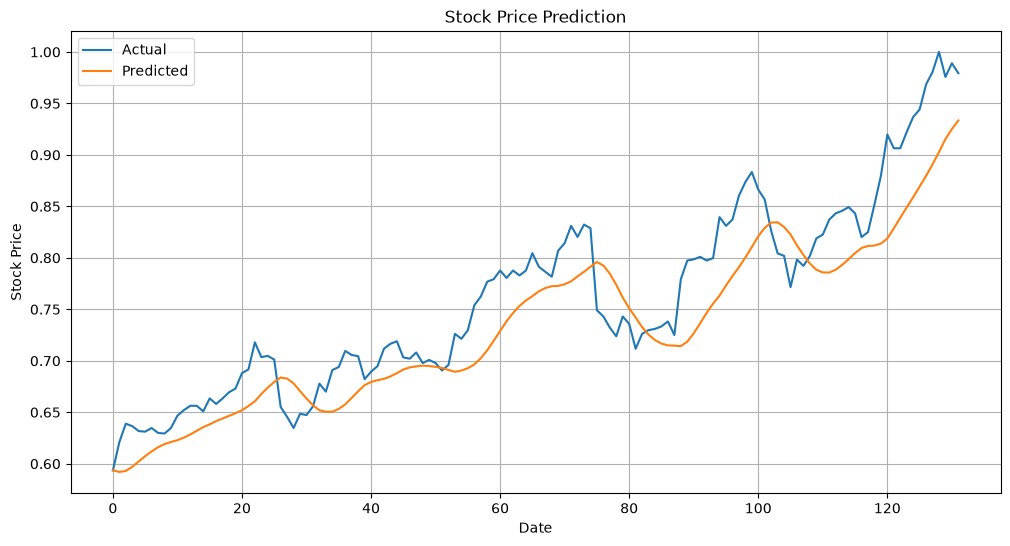

In [225]:
#2
plt.figure(figsize=(12, 6))
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Stock Price Prediction")
plt.plot(testY, label='Actual')
plt.plot(testPredict, label='Predicted')
plt.grid(True)
plt.legend()
plt.show()

For this study, we will focus on the closing price, as it represents the final market sentiment for each trading day.